
# **Apnea prediction using Physciological Time Series**

**Install**  **Required** **Libraries**

In [1]:
!pip install numpy pandas torch scikit-learn shap


In [2]:

import numpy as np
import pandas as pd

np.random.seed(42)

num_samples = 1000
time_steps = 50  # sequence length

data = []
labels = []

for i in range(num_samples):

    # NORMAL CASE
    if np.random.rand() > 0.3:
        ecg = np.sin(np.linspace(0, 10, time_steps)) + np.random.normal(0, 0.1, time_steps)
        respiration = np.sin(np.linspace(0, 5, time_steps)) + np.random.normal(0, 0.1, time_steps)
        spo2 = np.random.normal(96, 1, time_steps)
        hr = np.random.normal(120, 5, time_steps)   # neonatal HR
        airflow = np.sin(np.linspace(0, 5, time_steps)) + np.random.normal(0, 0.1, time_steps)

        label = 0

    # APNEA CASE
    else:
        ecg = np.sin(np.linspace(0, 10, time_steps)) + np.random.normal(0, 0.2, time_steps)
        respiration = np.zeros(time_steps) + np.random.normal(0, 0.05, time_steps)  # flat breathing
        spo2 = np.random.normal(85, 3, time_steps)  # drop in oxygen
        hr = np.random.normal(100, 10, time_steps)  # irregular HR
        airflow = np.zeros(time_steps)  # no airflow

        label = 1

    row = np.concatenate([ecg, respiration, spo2, hr, airflow])
    data.append(row)
    labels.append(label)

# Create DataFrame
columns = []

signals = ['ECG', 'Resp', 'SpO2', 'HR', 'Airflow']
for signal in signals:
    for t in range(time_steps):
        columns.append(f"{signal}_{t}")

df = pd.DataFrame(data, columns=columns)
df['label'] = labels

# Save dataset
df.to_csv("neonatal_apnea_dataset.csv", index=False)

print("Dataset created successfully!")
print(df.head())



Dataset created successfully!
      ECG_0     ECG_1     ECG_2     ECG_3     ECG_4     ECG_5     ECG_6  \
0 -0.111188  0.234558  0.424828  0.675758  0.670547  0.799805  0.883495   
1  0.424431  0.409161  0.093050  0.477859  0.982017  0.710788  1.029397   
2 -0.044668  0.155101  0.315374  0.518803  0.585226  0.833168  0.946380   
3 -0.052272  0.307569  0.326490  0.433860  0.572972  0.912923  0.812590   
4 -0.071087  0.135756  0.404345  0.551766  0.823685  0.818024  0.991183   

      ECG_7     ECG_8     ECG_9  ...  Airflow_41  Airflow_42  Airflow_43  \
0  0.897495  0.736833  1.059883  ...   -1.030369   -0.987529   -0.781637   
1  1.144830  0.812701  0.952941  ...    0.000000    0.000000    0.000000   
2  0.761623  0.987893  0.969060  ...   -0.957497   -0.886882   -0.922492   
3  1.165382  0.789895  1.134492  ...   -0.776210   -0.845327   -0.957685   
4  0.987011  1.025054  0.941841  ...   -0.879378   -1.007267   -0.892664   

   Airflow_44  Airflow_45  Airflow_46  Airflow_47  Airflow_48 

**Load** **Data**

In [3]:
import pandas as pd

df = pd.read_csv("neonatal_apnea_dataset.csv")
print(df.shape)
df.head()



(1000, 251)


,ECG_0,ECG_1,ECG_2,ECG_3,ECG_4,ECG_5,ECG_6,ECG_7,ECG_8,ECG_9,...,Airflow_41,Airflow_42,Airflow_43,Airflow_44,Airflow_45,Airflow_46,Airflow_47,Airflow_48,Airflow_49,label
0,-0.111188,0.234558,0.424828,0.675758,0.670547,0.799805,0.883495,0.897495,0.736833,1.059883,...,-1.030369,-0.987529,-0.781637,-1.008753,-1.024527,-0.968052,-1.157736,-0.888293,-0.832284,0
1,0.424431,0.409161,0.093050,0.477859,0.982017,0.710788,1.029397,1.144830,0.812701,0.952941,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,-0.044668,0.155101,0.315374,0.518803,0.585226,0.833168,0.946380,0.761623,0.987893,0.969060,...,-0.957497,-0.886882,-0.922492,-0.810689,-1.093451,-1.065552,-1.090249,-1.149809,-0.782456,0
3,-0.052272,0.307569,0.326490,0.433860,0.572972,0.912923,0.812590,1.165382,0.789895,1.134492,...,-0.776210,-0.845327,-0.957685,-0.790665,-1.099751,-1.152381,-1.065704,-0.987390,-0.934590,0
4,-0.071087,0.135756,0.404345,0.551766,0.823685,0.818024,0.991183,0.987011,1.025054,0.941841,...,-0.879378,-1.007267,-0.892664,-0.790666,-0.970514,-0.983781,-1.090236,-0.843090,-0.966439,0


**Preprocess** **Data**




In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('label', axis=1).values
y = df['label'].values

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape (VERY IMPORTANT)
X = X.reshape(X.shape[0], 5, 50)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


**Define** **Model**

In [5]:
import torch.nn as nn

class ApneaModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(5, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.bigru = nn.GRU(32, 64, batch_first=True, bidirectional=True)

        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Linear(128, 2)
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)
        x, _ = self.bigru(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x


**Train** **Model**

In [6]:
model = ApneaModel()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")


/tmp/ipykernel_14023/3632805944.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


Epoch 1, Loss: 0.9652407765388489
Epoch 2, Loss: 0.8273449540138245
Epoch 3, Loss: 0.14351744949817657
Epoch 4, Loss: 0.009911461733281612
Epoch 5, Loss: 0.01642383262515068
Epoch 6, Loss: 0.023241134360432625
Epoch 7, Loss: 0.00618963735178113
Epoch 8, Loss: 0.0012611239217221737
Epoch 9, Loss: 0.0006185914971865714
Epoch 10, Loss: 0.00046244857367128134


**Test** **Accuracy**

In [7]:
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

accuracy = (predicted == y_test).sum().item() / len(y_test)

print("Accuracy:", accuracy)


Accuracy: 1.0


**Confusion Matrix**

Confusion Matrix:
 [[146   0]
 [  0  54]]


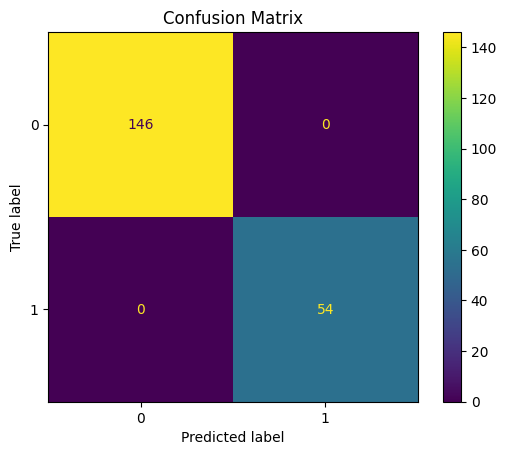


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      1.00      1.00        54

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.argmax(outputs, dim=1)
y_true = y_test.cpu().numpy()
y_pred = predictions.cpu().numpy()
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

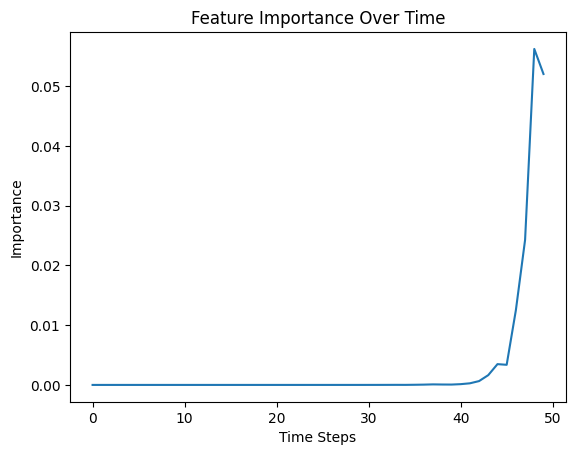

In [9]:
import matplotlib.pyplot as plt

model.eval()

sample = X_test[0].unsqueeze(0)
sample.requires_grad = True

output = model(sample)

pred_class = torch.argmax(output)

model.zero_grad()
output[0, pred_class].backward()

importance = sample.grad.abs().mean(dim=1).squeeze().detach().numpy()

plt.plot(importance)
plt.title("Feature Importance Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Importance")
plt.show()
